**Basit Doğrusal Regresyon — Sezgiden Koda**

Bir şeyi tahmin etmeye çalıştığınız her an — bir ev fiyatı, bir maaş, gelecek ayın satışları — farkında olsanız da olmasanız da aslında regresyon yapıyorsunuz. Hadi bunu düzgünce anlayalım.

**Basit Doğrusal Regresyon Nedir?**

Basit Regresyon, bağımlı "y" değişkenini tahmin etmek için bir prediktif model oluşturmaya yarayan istatistiksel bir yöntemdir. Daha basit bir ifadeyle, bir bağımsız değişken ile bir bağımlı değişken arasındaki ilişkiyi analiz etme ve ölçme yöntemidir.

Bunu somutlaştıralım. Yalnızca 2 sütunlu bir veri setimiz olduğunu hayal edin: **ev fiyatı** ve **ev büyüklüğü**. Amacımız, büyüklüğe göre fiyatı tahmin etmek. Matematiksel olarak şöyle ifade ederiz:

**f(x) = y = mx + b**

Ama asıl soru şu — **"m"** ve **"b"** tam olarak nedir?

**Doğrunun Arkasındaki Matematik**

Matematiksel açıdan, doğrusal regresyon iki değişken arasına çizilen bir **yaklaşım doğrusudur**. Bu doğrunun denklemi **y = mx + b**'dir; burada:
- **m** eğimdir — x bir birim arttığında y ne kadar değişir
- **b** y-kesimidir — doğrunun y eksenini kestiği nokta

Modelin amacı, en doğru tahminleri üretecek m ve b değerlerini bulmaktır. Bunun için modelin ne kadar yanıldığını ölçmemiz gerekir — işte burada **kayıp fonksiyonu** devreye girer.

**Kayıp Fonksiyonu ve OLS**

**J(m, b)** kayıp fonksiyonu, modelimizin toplam hatasını ölçer. Matematiksel olarak şöyle görünür:

**J(m, b) = Σ(y − ŷ)²**

Burada **y** gerçek değer, **ŷ** ise tahmin edilen değerdir. Farkları karelerini alarak büyük hataları daha fazla cezalandırır ve pozitif ile negatif hataların birbirini sıfırlamasını önleriz.

Bunu nasıl minimize ederiz? Amaç, kareli hataların toplamını minimize etmektir — bu **OLS hedefidir**. sklearn bunu arka planda **(XᵀX)⁻¹Xᵀy** normal denklemini doğrudan hesaplamaktan sayısal olarak daha kararlı olan **SVD ayrıştırması** ile çözer.


### İşte Python'da yazılmış örnek bir basit liner regresyon uygulaması

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression



### Örnek veri kümesinin tanımlanması ve doğrusal regresyon modelinin uyarlanması

In [2]:
# Veri seti: ev büyüklüğü (m²) ve fiyat (1000 $)
size = np.array([50, 70, 90, 110, 130, 150, 170]).reshape(-1, 1)
price = np.array([150, 200, 250, 290, 340, 400, 450])

# Modeli oluştur ve eğit
model = LinearRegression()
model.fit(size, price)

m = model.coef_[0]
b = model.intercept_

print(f"Eğim       (m): {m:.2f}")
print(f"Y-kesimi   (b): {b:.2f}")
print(f"Denklem      : y = {m:.2f}x + {b:.2f}")

Eğim       (m): 2.48
Y-kesimi   (b): 24.11
Denklem      : y = 2.48x + 24.11


### Metriklerin kontrol edilmesi ve görselleştirilmesi

R² Skoru     : 1.00

120 m² ev için tahmin edilen fiyat: $322.0k


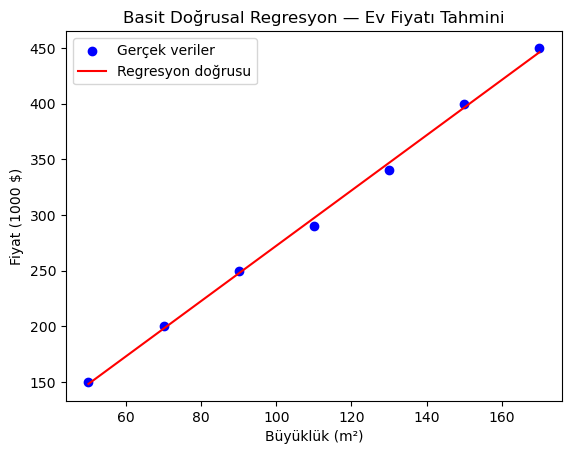

In [3]:
print(f"R² Skoru     : {model.score(size, price):.2f}")

predicted = model.predict([[120]])
print(f"\n120 m² ev için tahmin edilen fiyat: ${predicted[0]:.1f}k")

# Görselleştirme
plt.scatter(size, price, color='blue', label='Gerçek veriler')
plt.plot(size, model.predict(size), color='red', label='Regresyon doğrusu')
plt.xlabel('Büyüklük (m²)')
plt.ylabel('Fiyat (1000 $)')
plt.title('Basit Doğrusal Regresyon — Ev Fiyatı Tahmini')
plt.legend()
plt.show()



**Önemli Bir Sınırlama**

Basit Doğrusal Regresyon, değişkenler arasında **doğrusal bir ilişki** olduğunu varsayar. Gerçek ilişki eğrisel veya daha karmaşıksa — ne kadar ince ayar yaparsanız yapın model kötü performans gösterir. Modeli uygulamadan önce her zaman verilerinizi görselleştirin — basit bir scatter plot size çok zaman kazandırabilir.

**Son Düşünce**

Basit Doğrusal Regresyon, makine öğrenmesindeki en zarif araçlardan biridir. Güçlü olduğu için değil, **yorumlanabilir** olduğu için. Denkleme bakarak modelin ne öğrendiğini anında anlayabilirsiniz. Modellerin giderek daha karmaşık ve şeffaf olmayan bir hal aldığı bu alanda, bu netlik hâlâ gerçek bir değer taşımaktadır.

---
